In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load monthly signals
monthly = pd.read_parquet('../data/working/monthly_signals.parquet')
monthly['month'] = pd.to_datetime(monthly['month'])

# Load membership panel — tells us who's in the index each month
membership = pd.read_parquet('../data/raw/membership_panel.parquet')
membership['snapshot_date'] = pd.to_datetime(membership['snapshot_date'])
membership['month'] = membership['snapshot_date'].dt.to_period('M').dt.to_timestamp()

# Load benchmark
bench = pd.read_parquet('../data/working/benchmark_train.parquet')
bench['date'] = pd.to_datetime(bench['date'])

# Create monthly benchmark returns
bench_monthly = (bench[bench['field'] == 'TOT_RETURN_INDEX_GROSS_DVDS']
                 .sort_values('date')
                 .assign(month=lambda x: x['date'].dt.to_period('M').dt.to_timestamp())
                 .groupby('month')['value']
                 .last()
                 .pct_change()
                 .rename('bench_ret'))

# Load SONIA — monthly risk-free rate
sonia = pd.read_parquet('../data/working/sonia_train.parquet')
sonia['date'] = pd.to_datetime(sonia['date'])
sonia_monthly = (sonia.assign(month=sonia['date'].dt.to_period('M').dt.to_timestamp())
                 .groupby('month')['value']
                 .mean()
                 .rename('sonia_annual'))
sonia_monthly = sonia_monthly / 100 / 12  # convert annual % to monthly decimal

print(f"Monthly signals: {len(monthly):,} rows, {monthly['ticker'].nunique()} tickers")
print(f"Membership: {membership['month'].nunique()} months")
print(f"Benchmark months: {len(bench_monthly)}")
print(f"SONIA months: {len(sonia_monthly)}")
print(f"\nBacktest will run from 2010-07 to 2023-12")

Monthly signals: 79,823 rows, 635 tickers
Membership: 192 months
Benchmark months: 174
SONIA months: 174

Backtest will run from 2010-07 to 2023-12


In [2]:
def form_portfolio(signals_month, signal_col, direction='long_top', vol_filter=False):
    """
    Form a quintile portfolio for one month.
   
    Parameters:
    - signals_month: DataFrame of signals for one month (already filtered to index members)
    - signal_col: which signal to rank on ('momentum_12_1', 'reversal_1m', 'vol_90d')
    - direction: 'long_top' (buy highest signal) or 'long_bottom' (buy lowest signal)
    - vol_filter: if True, only include stocks passing volume confirmation
   
    Returns: list of selected tickers
    """
    df = signals_month.dropna(subset=[signal_col]).copy()
   
    # Apply volume filter if requested
    if vol_filter:
        df = df[df['vol_confirm'] == 1]
   
    if len(df) < 10:  # not enough stocks to form a meaningful portfolio
        return []
   
    # Rank by signal
    df['rank'] = df[signal_col].rank(pct=True)
   
    # Select quintile
    if direction == 'long_top':
        selected = df[df['rank'] >= 0.8]  # top 20%
    else:
        selected = df[df['rank'] <= 0.2]  # bottom 20%
   
    return selected['ticker'].tolist()


def run_backtest(monthly, membership, signal_col, direction, vol_filter=False,
                 start_month='2010-07-01'):
    """
    Run walk-forward backtest for a single strategy.
   
    Returns: DataFrame with monthly portfolio returns
    """
    start = pd.Timestamp(start_month)
    months = sorted(monthly['month'].unique())
    months = [m for m in months if m >= start]
   
    results = []
   
    for i, month in enumerate(months):
        # Get current index members
        mem = membership[membership['month'] == month]
        if len(mem) == 0:
            # Find nearest prior membership snapshot
            prior = membership[membership['month'] <= month]
            if len(prior) == 0:
                continue
            mem = prior[prior['month'] == prior['month'].max()]
       
        index_members = set(mem['ticker'].unique())
       
        # Get signals for this month — only index members
        sig = monthly[(monthly['month'] == month) &
                      (monthly['ticker'].isin(index_members))]
       
        # Form portfolio based on signal
        portfolio = form_portfolio(sig, signal_col, direction, vol_filter)
       
        if len(portfolio) == 0:
            continue
       
        # Get NEXT month's returns for these stocks (out-of-sample)
        if i + 1 >= len(months):
            break
        next_month = months[i + 1]
       
        next_rets = monthly[(monthly['month'] == next_month) &
                            (monthly['ticker'].isin(portfolio))]
       
        if len(next_rets) == 0:
            continue
       
        # Equal-weighted portfolio return
        port_ret = next_rets['monthly_ret'].mean()
       
        results.append({
            'formation_month': month,
            'holding_month': next_month,
            'port_ret': port_ret,
            'n_stocks': len(portfolio),
            'n_with_returns': len(next_rets),
            'portfolio': portfolio
        })
   
    return pd.DataFrame(results)

print("Backtest engine defined.")
print("  form_portfolio(): ranks stocks, selects quintile")
print("  run_backtest(): walks forward month by month")

Backtest engine defined.
  form_portfolio(): ranks stocks, selects quintile
  run_backtest(): walks forward month by month


In [3]:
# Define the six strategies
strategies = {
    'Momentum':           {'signal_col': 'momentum_12_1', 'direction': 'long_top',    'vol_filter': False},
    'Momentum + Vol':     {'signal_col': 'momentum_12_1', 'direction': 'long_top',    'vol_filter': True},
    'Reversal':           {'signal_col': 'reversal_1m',   'direction': 'long_bottom', 'vol_filter': False},
    'Reversal + Vol':     {'signal_col': 'reversal_1m',   'direction': 'long_bottom', 'vol_filter': True},
    'Low-Vol':            {'signal_col': 'vol_90d',       'direction': 'long_bottom', 'vol_filter': False},
    'Low-Vol + Vol':      {'signal_col': 'vol_90d',       'direction': 'long_bottom', 'vol_filter': True},
}

results = {}
for name, params in strategies.items():
    print(f"Running {name}...", end=' ')
    df = run_backtest(monthly, membership, **params)
    results[name] = df
    print(f"OK — {len(df)} months, avg {df['n_stocks'].mean():.0f} stocks")

print("\n=== ALL STRATEGIES COMPLETE ===")
for name, df in results.items():
    avg_ret = df['port_ret'].mean() * 100
    print(f"  {name:25s}  months: {len(df):3d}  avg stocks: {df['n_stocks'].mean():.0f}  avg monthly ret: {avg_ret:+.2f}%")

Running Momentum... OK — 161 months, avg 50 stocks
Running Momentum + Vol... OK — 161 months, avg 23 stocks
Running Reversal... OK — 161 months, avg 50 stocks
Running Reversal + Vol... OK — 161 months, avg 23 stocks
Running Low-Vol... OK — 161 months, avg 50 stocks
Running Low-Vol + Vol... OK — 161 months, avg 23 stocks

=== ALL STRATEGIES COMPLETE ===
  Momentum                   months: 161  avg stocks: 50  avg monthly ret: +1.19%
  Momentum + Vol             months: 161  avg stocks: 23  avg monthly ret: +1.22%
  Reversal                   months: 161  avg stocks: 50  avg monthly ret: +0.54%
  Reversal + Vol             months: 161  avg stocks: 23  avg monthly ret: +0.54%
  Low-Vol                    months: 161  avg stocks: 50  avg monthly ret: +0.74%
  Low-Vol + Vol              months: 161  avg stocks: 23  avg monthly ret: +0.76%


In [5]:
import scipy.stats as stats

def performance_metrics(port_returns, bench_returns, rf_returns, strategy_name):
    """Compute comprehensive performance metrics for a strategy."""
    # Align dates
    df = pd.DataFrame({
        'port': port_returns.set_index('holding_month')['port_ret'],
        'bench': bench_returns,
        'rf': rf_returns
    }).dropna()
   
    n_months = len(df)
    if n_months < 12:
        return None
   
    # Excess returns
    df['excess'] = df['port'] - df['rf']
    df['bench_excess'] = df['bench'] - df['rf']
   
    # Annualised return
    total_ret = (1 + df['port']).prod()
    ann_ret = total_ret ** (12 / n_months) - 1
   
    # Benchmark annualised return
    bench_total = (1 + df['bench']).prod()
    bench_ann = bench_total ** (12 / n_months) - 1
   
    # Annualised volatility
    ann_vol = df['port'].std() * np.sqrt(12)
   
    # Sharpe ratio
    sharpe = (df['excess'].mean() / df['excess'].std()) * np.sqrt(12)
   
    # CAPM alpha and beta (OLS regression)
    from numpy.linalg import lstsq
    X = np.column_stack([np.ones(n_months), df['bench_excess'].values])
    y = df['excess'].values
    coeffs, _, _, _ = lstsq(X, y, rcond=None)
    alpha_monthly = coeffs[0]
    beta = coeffs[1]
   
    # Alpha annualised
    alpha_annual = alpha_monthly * 12
   
    # Residuals for t-stat
    residuals = y - X @ coeffs
    se = np.sqrt(np.sum(residuals**2) / (n_months - 2))
    X_inv = np.linalg.inv(X.T @ X)
    alpha_se = se * np.sqrt(X_inv[0, 0])
    alpha_tstat = alpha_monthly / alpha_se
   
    # Newey-West adjustment (3 lags)
    def newey_west_se(residuals, X, lags=3):
        n = len(residuals)
        k = X.shape[1]
        S = np.zeros((k, k))
        for l in range(lags + 1):
            weight = 1 if l == 0 else 1 - l / (lags + 1)
            for t in range(l, n):
                x_t = X[t].reshape(-1, 1)
                x_tl = X[t - l].reshape(-1, 1)
                S += weight * residuals[t] * residuals[t - l] * (x_t @ x_tl.T + (x_tl @ x_t.T if l > 0 else 0))
        S /= n
        bread = np.linalg.inv(X.T @ X / n)
        V = bread @ S @ bread / n
        return np.sqrt(V[0, 0])
   
    nw_se = newey_west_se(residuals, X)
    alpha_tstat_nw = alpha_monthly / nw_se
   
    # Max drawdown
    cum_ret = (1 + df['port']).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    max_dd = drawdown.min()
   
    # Information ratio
    tracking_error = (df['port'] - df['bench']).std() * np.sqrt(12)
    ir = (ann_ret - bench_ann) / tracking_error if tracking_error > 0 else 0
   
    return {
        'Strategy': strategy_name,
        'Months': n_months,
        'Ann. Return': f"{ann_ret:.1%}",
        'Ann. Vol': f"{ann_vol:.1%}",
        'Sharpe': f"{sharpe:.2f}",
        'CAPM Alpha (ann.)': f"{alpha_annual:.1%}",
        'Alpha t-stat': f"{alpha_tstat:.2f}",
        'Alpha t-stat (NW)': f"{alpha_tstat_nw:.2f}",
        'Beta': f"{beta:.2f}",
        'Max Drawdown': f"{max_dd:.1%}",
        'Info Ratio': f"{ir:.2f}",
        'Benchmark Ann.': f"{bench_ann:.1%}",
    }

# Run metrics for all strategies
metrics = []
for name, df in results.items():
    m = performance_metrics(df, bench_monthly, sonia_monthly, name)
    if m:
        metrics.append(m)

metrics_df = pd.DataFrame(metrics).set_index('Strategy')
print("=== PERFORMANCE METRICS (2010-07 to 2023-12) ===\n")
print(metrics_df.to_string())

=== PERFORMANCE METRICS (2010-07 to 2023-12) ===

                Months Ann. Return Ann. Vol Sharpe CAPM Alpha (ann.) Alpha t-stat Alpha t-stat (NW)  Beta Max Drawdown Info Ratio Benchmark Ann.
Strategy                                                                                                                                        
Momentum           161       13.9%    15.5%   0.87              5.9%         3.22              3.21  0.94       -29.7%       0.87           8.1%
Momentum + Vol     161       14.3%    15.7%   0.88              6.5%         2.97              2.82  0.91       -29.6%       0.78           8.1%
Reversal           161        4.3%    21.0%   0.27             -4.9%        -2.20             -2.49  1.30       -43.5%      -0.41           8.1%
Reversal + Vol     161        3.6%    23.2%   0.24             -5.3%        -1.64             -1.51  1.34       -58.2%      -0.35           8.1%
Low-Vol            161        8.7%     9.8%   0.82              3.1%         3.2

In [6]:
# === TRANSACTION COST MODEL ===
# Two components:
# 1. Stamp duty: 0.5% (50bp) on every buy
# 2. Spread cost: Corwin-Schultz estimate from daily high-low

# Compute Corwin-Schultz spread for each stock-month
train = pd.read_parquet('../data/working/equities_train.parquet')
train['date'] = pd.to_datetime(train['date'])
train = train.sort_values(['ticker', 'date'])

def corwin_schultz_monthly(group):
    """Estimate monthly average bid-ask spread from daily high-low."""
    h = group['PX_HIGH'].values
    l = group['PX_LOW'].values
   
    if len(h) < 5 or np.any(l <= 0) or np.any(np.isnan(h)) or np.any(np.isnan(l)):
        return np.nan
   
    # Two-day estimates
    spreads = []
    for t in range(1, len(h)):
        if h[t] <= 0 or l[t] <= 0 or h[t-1] <= 0 or l[t-1] <= 0:
            continue
        beta = (np.log(h[t]/l[t]))**2 + (np.log(h[t-1]/l[t-1]))**2
        gamma = (np.log(max(h[t], h[t-1]) / min(l[t], l[t-1])))**2
       
        alpha_val = (np.sqrt(2*beta) - np.sqrt(beta)) / (3 - 2*np.sqrt(2)) \
                    - np.sqrt(gamma / (3 - 2*np.sqrt(2)))
       
        spread = 2 * (np.exp(alpha_val) - 1) / (1 + np.exp(alpha_val))
        spread = max(spread, 0)  # clip negatives
        spreads.append(spread)
   
    return np.median(spreads) if spreads else np.nan

print("Computing Corwin-Schultz spreads (takes 2-3 minutes)...")
train['year_month'] = train['date'].dt.to_period('M')
cs_spreads = (train.groupby(['ticker', 'year_month'])
              .apply(corwin_schultz_monthly)
              .reset_index()
              .rename(columns={'year_month': 'month', 0: 'cs_spread'}))
cs_spreads['month'] = cs_spreads['month'].dt.to_timestamp()

print(f"Corwin-Schultz spreads computed: {len(cs_spreads):,} observations")
print(f"\nSpread distribution:")
print(cs_spreads['cs_spread'].describe())
print(f"\nMedian spread: {cs_spreads['cs_spread'].median()*100:.2f}%")

Computing Corwin-Schultz spreads (takes 2-3 minutes)...
Corwin-Schultz spreads computed: 80,226 observations

Spread distribution:
count    78177.000000
mean         0.003938
std          0.004619
min          0.000000
25%          0.000000
50%          0.002707
75%          0.006054
max          0.064500
Name: cs_spread, dtype: float64

Median spread: 0.27%


In [7]:
# Compute turnover and net-of-cost returns for each strategy

STAMP_DUTY = 0.005  # 0.5% on buys

def compute_net_returns(result_df, cs_spreads, strategy_name):
    """Add turnover and net-of-cost returns to a strategy's results."""
   
    result_df = result_df.copy()
   
    # Compute turnover: fraction of portfolio that changes each month
    turnovers = []
    spread_costs = []
   
    for i in range(len(result_df)):
        current_port = set(result_df.iloc[i]['portfolio'])
       
        if i == 0:
            # First month: 100% turnover (buying everything)
            turnover = 1.0
        else:
            prev_port = set(result_df.iloc[i-1]['portfolio'])
            # Stocks entering the portfolio
            new_stocks = current_port - prev_port
            # Stocks leaving
            old_stocks = prev_port - current_port
            # One-way turnover: fraction replaced
            turnover = len(new_stocks) / max(len(current_port), 1)
       
        turnovers.append(turnover)
       
        # Average spread cost for stocks traded this month
        month = result_df.iloc[i]['formation_month']
        month_spreads = cs_spreads[cs_spreads['month'] == month]
        port_spreads = month_spreads[month_spreads['ticker'].isin(current_port)]
       
        if len(port_spreads) > 0:
            avg_spread = port_spreads['cs_spread'].median()
        else:
            avg_spread = cs_spreads['cs_spread'].median()  # fallback to overall median
       
        spread_costs.append(avg_spread)
   
    result_df['turnover'] = turnovers
    result_df['spread_cost'] = spread_costs
   
    # Transaction cost per month:
    # Buys: turnover * (spread/2 + stamp_duty)
    # Sells: turnover * (spread/2)
    # Total: turnover * (spread + stamp_duty)
    result_df['tc_monthly'] = result_df['turnover'] * (result_df['spread_cost'] + STAMP_DUTY)
   
    # Net return
    result_df['port_ret_net'] = result_df['port_ret'] - result_df['tc_monthly']
   
    return result_df

# Apply to all strategies
results_net = {}
print("=== TURNOVER AND TRANSACTION COSTS ===\n")
for name, df in results.items():
    df_net = compute_net_returns(df, cs_spreads, name)
    results_net[name] = df_net
   
    avg_turnover = df_net['turnover'].iloc[1:].mean()  # exclude first month
    avg_tc = df_net['tc_monthly'].iloc[1:].mean() * 100
    avg_gross = df_net['port_ret'].mean() * 100
    avg_net = df_net['port_ret_net'].mean() * 100
   
    print(f"{name:25s}  turnover: {avg_turnover:.0%}  avg TC: {avg_tc:.2f}%/mo  "
          f"gross: {avg_gross:+.2f}%/mo  net: {avg_net:+.2f}%/mo")

=== TURNOVER AND TRANSACTION COSTS ===

Momentum                   turnover: 25%  avg TC: 0.22%/mo  gross: +1.19%/mo  net: +0.97%/mo
Momentum + Vol             turnover: 68%  avg TC: 0.59%/mo  gross: +1.22%/mo  net: +0.64%/mo
Reversal                   turnover: 77%  avg TC: 0.71%/mo  gross: +0.54%/mo  net: -0.17%/mo
Reversal + Vol             turnover: 86%  avg TC: 0.78%/mo  gross: +0.54%/mo  net: -0.24%/mo
Low-Vol                    turnover: 11%  avg TC: 0.08%/mo  gross: +0.74%/mo  net: +0.66%/mo
Low-Vol + Vol              turnover: 61%  avg TC: 0.42%/mo  gross: +0.76%/mo  net: +0.33%/mo


In [8]:
# Recompute performance metrics using NET returns

def performance_metrics_net(result_df, bench_returns, rf_returns, strategy_name):
    """Performance metrics using net-of-cost returns."""
    df = pd.DataFrame({
        'port': result_df.set_index('holding_month')['port_ret_net'],
        'bench': bench_returns,
        'rf': rf_returns
    }).dropna()
   
    n = len(df)
    if n < 12:
        return None
   
    df['excess'] = df['port'] - df['rf']
    df['bench_excess'] = df['bench'] - df['rf']
   
    # Annualised return
    total = (1 + df['port']).prod()
    ann_ret = total ** (12 / n) - 1
    bench_total = (1 + df['bench']).prod()
    bench_ann = bench_total ** (12 / n) - 1
   
    # Vol and Sharpe
    ann_vol = df['port'].std() * np.sqrt(12)
    sharpe = (df['excess'].mean() / df['excess'].std()) * np.sqrt(12)
   
    # CAPM alpha and beta
    X = np.column_stack([np.ones(n), df['bench_excess'].values])
    y = df['excess'].values
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    alpha_m = coeffs[0]
    beta = coeffs[1]
    alpha_ann = alpha_m * 12
   
    # Newey-West t-stat
    residuals = y - X @ coeffs
    def nw_se(resid, X, lags=3):
        nn = len(resid)
        S = np.zeros((X.shape[1], X.shape[1]))
        for l in range(lags + 1):
            w = 1 if l == 0 else 1 - l / (lags + 1)
            for t in range(l, nn):
                xt = X[t].reshape(-1, 1)
                xtl = X[t - l].reshape(-1, 1)
                S += w * resid[t] * resid[t - l] * (xt @ xtl.T + (xtl @ xt.T if l > 0 else 0))
        S /= nn
        bread = np.linalg.inv(X.T @ X / nn)
        return np.sqrt((bread @ S @ bread / nn)[0, 0])
   
    alpha_tstat_nw = alpha_m / nw_se(residuals, X)
   
    # Max drawdown
    cum = (1 + df['port']).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
   
    # Turnover
    avg_turnover = result_df['turnover'].iloc[1:].mean()
    avg_tc = result_df['tc_monthly'].iloc[1:].mean() * 12
   
    return {
        'Strategy': strategy_name,
        'Ann. Return (net)': f"{ann_ret:.1%}",
        'Ann. Vol': f"{ann_vol:.1%}",
        'Sharpe (net)': f"{sharpe:.2f}",
        'Alpha (net, ann.)': f"{alpha_ann:.1%}",
        'Alpha t (NW)': f"{alpha_tstat_nw:.2f}",
        'Beta': f"{beta:.2f}",
        'Max DD': f"{max_dd:.1%}",
        'Turnover (mo)': f"{avg_turnover:.0%}",
        'TC (ann.)': f"{avg_tc:.1%}",
        'Benchmark': f"{bench_ann:.1%}",
    }

# Build final table
final_metrics = []
for name, df in results_net.items():
    m = performance_metrics_net(df, bench_monthly, sonia_monthly, name)
    if m:
        final_metrics.append(m)

final_df = pd.DataFrame(final_metrics).set_index('Strategy')

print("=" * 80)
print("FINAL RESULTS: NET-OF-COST PERFORMANCE (2010-07 to 2023-12)")
print("=" * 80)
print(final_df.to_string())
print("\nStatistical significance: |t-stat| > 1.96 = 5% level, > 2.58 = 1% level")

# Save results
final_df.to_parquet('../data/working/final_results.parquet')
final_df.to_excel('../data/final_results.xlsx')
print("\nResults saved to data/final_results.xlsx")

FINAL RESULTS: NET-OF-COST PERFORMANCE (2010-07 to 2023-12)
               Ann. Return (net) Ann. Vol Sharpe (net) Alpha (net, ann.) Alpha t (NW)  Beta  Max DD Turnover (mo) TC (ann.) Benchmark
Strategy                                                                                                                             
Momentum                   10.9%    15.4%         0.70              3.2%         1.74  0.94  -32.7%           25%      2.6%      8.1%
Momentum + Vol              6.5%    15.7%         0.44             -0.6%        -0.24  0.91  -31.8%           68%      7.1%      8.1%
Reversal                   -4.2%    20.9%        -0.13            -13.3%        -6.80  1.29  -60.9%           77%      8.5%      8.1%
Reversal + Vol             -5.6%    23.1%        -0.16            -14.6%        -4.18  1.34  -72.3%           86%      9.3%      8.1%
Low-Vol                     7.7%     9.8%         0.72              2.1%         2.17  0.62  -20.2%           11%      0.9%      8.1%
Lo

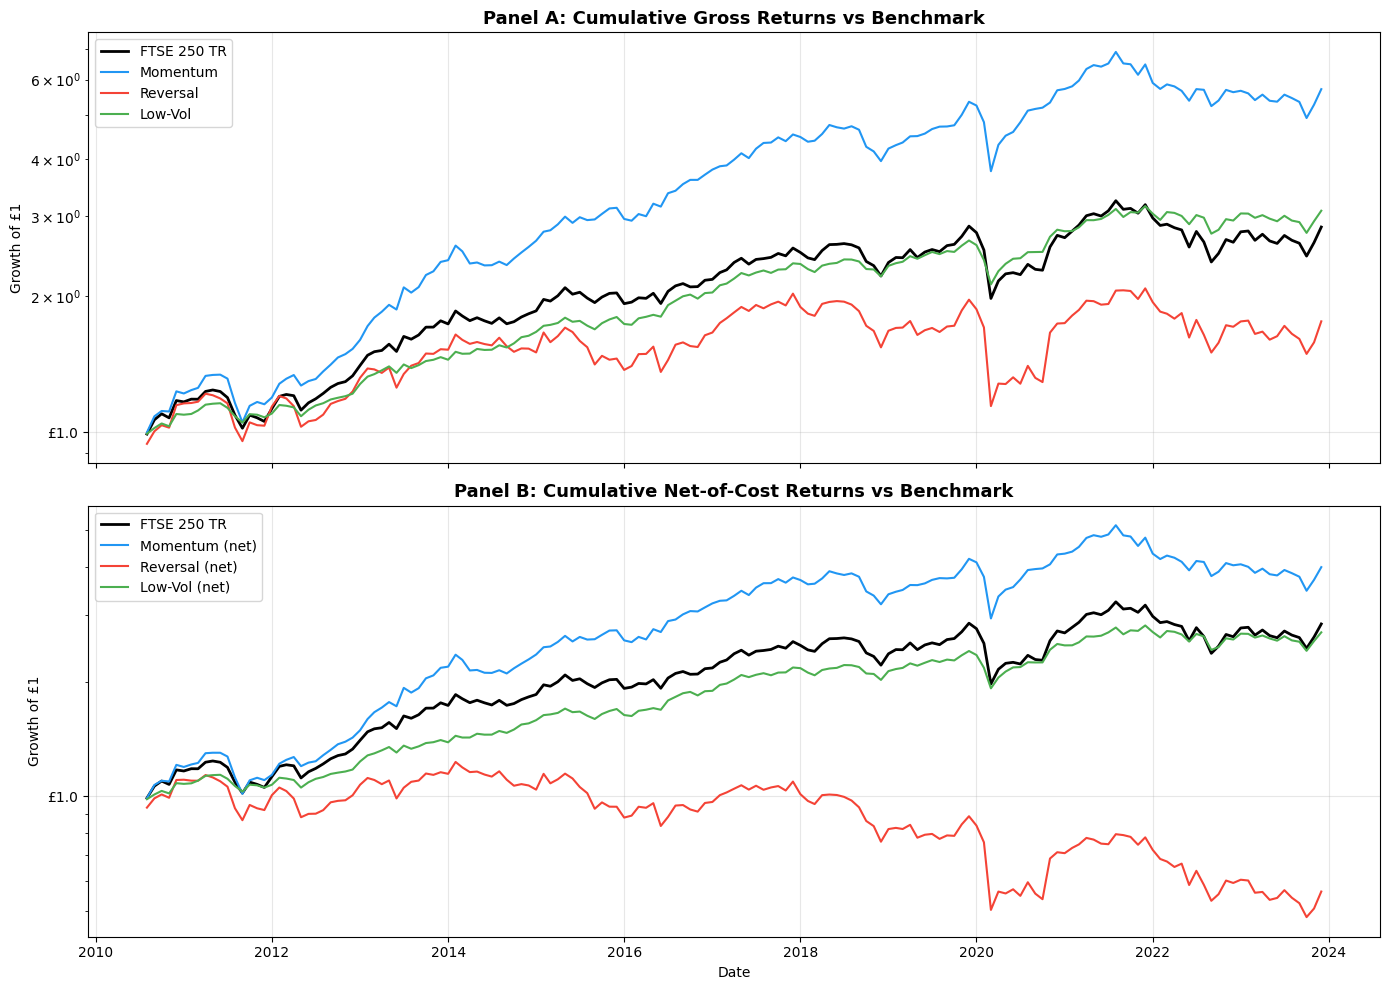

Chart saved to data/equity_curves.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel A: Gross returns
ax1 = axes[0]
ax1.set_title('Panel A: Cumulative Gross Returns vs Benchmark', fontsize=13, fontweight='bold')

# Benchmark cumulative
bench_cum = (1 + bench_monthly.loc[bench_monthly.index >= '2010-08-01']).cumprod()
ax1.plot(bench_cum.index, bench_cum.values, 'k-', linewidth=2, label='FTSE 250 TR')

colors = {'Momentum': '#2196F3', 'Reversal': '#F44336', 'Low-Vol': '#4CAF50'}
for name in ['Momentum', 'Reversal', 'Low-Vol']:
    df = results[name]
    cum = (1 + df.set_index('holding_month')['port_ret']).cumprod()
    ax1.plot(cum.index, cum.values, linewidth=1.5, label=name, color=colors[name])

ax1.set_ylabel('Growth of £1')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:.1f}'))

# Panel B: Net-of-cost returns
ax2 = axes[1]
ax2.set_title('Panel B: Cumulative Net-of-Cost Returns vs Benchmark', fontsize=13, fontweight='bold')

ax2.plot(bench_cum.index, bench_cum.values, 'k-', linewidth=2, label='FTSE 250 TR')

for name in ['Momentum', 'Reversal', 'Low-Vol']:
    df = results_net[name]
    cum = (1 + df.set_index('holding_month')['port_ret_net']).cumprod()
    ax2.plot(cum.index, cum.values, linewidth=1.5, label=f'{name} (net)', color=colors[name])

ax2.set_ylabel('Growth of £1')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:.1f}'))

plt.tight_layout()
plt.savefig('../data/equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/equity_curves.png")

In [10]:
# Save net-of-cost result series for each strategy
for name, df in results_net.items():
    safe_name = name.lower().replace(' ', '_').replace('+', 'plus')
    df.to_parquet(f'../data/working/backtest_{safe_name}.parquet')

# Save the monthly signals frame with all computed signals
monthly.to_parquet('../data/working/monthly_signals.parquet')

print("All backtest results saved to data/working/")
print("\nFiles created:")
for name in results_net:
    safe_name = name.lower().replace(' ', '_').replace('+', 'plus')
    print(f"  backtest_{safe_name}.parquet")

All backtest results saved to data/working/

Files created:
  backtest_momentum.parquet
  backtest_momentum_plus_vol.parquet
  backtest_reversal.parquet
  backtest_reversal_plus_vol.parquet
  backtest_low-vol.parquet
  backtest_low-vol_plus_vol.parquet


In [1]:
import pandas as pd
import numpy as np

# Load all results
strategies_train = {
    'Momentum': pd.read_parquet('../data/working/backtest_momentum.parquet'),
    'Momentum + Vol': pd.read_parquet('../data/working/backtest_momentum_plus_vol.parquet'),
    'Reversal': pd.read_parquet('../data/working/backtest_reversal.parquet'),
    'Reversal + Vol': pd.read_parquet('../data/working/backtest_reversal_plus_vol.parquet'),
    'Low-Vol': pd.read_parquet('../data/working/backtest_low-vol.parquet'),
    'Low-Vol + Vol': pd.read_parquet('../data/working/backtest_low-vol_plus_vol.parquet'),
}

# Load benchmark and SONIA
bench = pd.read_parquet('../data/working/benchmark_train.parquet')
bench['date'] = pd.to_datetime(bench['date'])
bench_monthly = (bench[bench['field'] == 'TOT_RETURN_INDEX_GROSS_DVDS']
                 .sort_values('date')
                 .assign(month=lambda x: x['date'].dt.to_period('M').dt.to_timestamp())
                 .groupby('month')['value']
                 .last()
                 .pct_change()
                 .rename('bench_ret'))

sonia = pd.read_parquet('../data/working/sonia_train.parquet')
sonia['date'] = pd.to_datetime(sonia['date'])
sonia_monthly = (sonia.assign(month=sonia['date'].dt.to_period('M').dt.to_timestamp())
                 .groupby('month')['value']
                 .mean()
                 .rename('sonia_annual'))
sonia_monthly = sonia_monthly / 100 / 12

def compute_extended_metrics(result_df, bench_returns, rf_returns, name):
    """Compute Sortino, Calmar, and all other ratios."""
    df = pd.DataFrame({
        'port': result_df.set_index('holding_month')['port_ret_net'],
        'bench': bench_returns,
        'rf': rf_returns
    }).dropna()
    
    n = len(df)
    df['excess'] = df['port'] - df['rf']
    
    # Annualised return
    total = (1 + df['port']).prod()
    ann_ret = total ** (12 / n) - 1
    
    # Annualised volatility
    ann_vol = df['port'].std() * np.sqrt(12)
    
    # Sharpe ratio
    sharpe = (df['excess'].mean() / df['excess'].std()) * np.sqrt(12)
    
    # --- SORTINO RATIO ---
    # Uses downside deviation (only negative excess returns)
    downside = df['excess'].copy()
    downside[downside > 0] = 0  # zero out positive returns
    downside_dev = np.sqrt((downside ** 2).mean()) * np.sqrt(12)
    sortino = (df['excess'].mean() * 12) / downside_dev if downside_dev > 0 else np.nan
    
    # --- MAX DRAWDOWN ---
    cum = (1 + df['port']).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    # --- CALMAR RATIO ---
    # Annualised return / absolute max drawdown
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    
    # CAPM alpha and beta
    df['bench_excess'] = df['bench'] - df['rf']
    X = np.column_stack([np.ones(n), df['bench_excess'].values])
    y = df['excess'].values
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    alpha_ann = coeffs[0] * 12
    beta = coeffs[1]
    
    # Newey-West t-stat on alpha
    residuals = y - X @ coeffs
    def nw_se(resid, X, lags=3):
        nn = len(resid)
        S = np.zeros((X.shape[1], X.shape[1]))
        for l in range(lags + 1):
            w = 1 if l == 0 else 1 - l / (lags + 1)
            for t in range(l, nn):
                xt = X[t].reshape(-1, 1)
                xtl = X[t - l].reshape(-1, 1)
                S += w * resid[t] * resid[t - l] * (xt @ xtl.T + (xtl @ xt.T if l > 0 else 0))
        S /= nn
        bread = np.linalg.inv(X.T @ X / nn)
        return np.sqrt((bread @ S @ bread / nn)[0, 0])
    
    alpha_tstat_nw = coeffs[0] / nw_se(residuals, X)
    
    # Benchmark annualised
    bench_ann = (1 + df['bench']).prod() ** (12 / n) - 1
    
    # Information ratio
    tracking = (df['port'] - df['bench']).std() * np.sqrt(12)
    ir = (ann_ret - bench_ann) / tracking if tracking > 0 else 0
    
    # Turnover
    avg_turnover = result_df['turnover'].iloc[1:].mean()
    
    return {
        'Strategy': name,
        'Ann. Return': ann_ret,
        'Ann. Vol': ann_vol,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max DD': max_dd,
        'Calmar': calmar,
        'Alpha (ann.)': alpha_ann,
        'Alpha t (NW)': alpha_tstat_nw,
        'Beta': beta,
        'Info Ratio': ir,
        'Turnover (mo)': avg_turnover,
        'Benchmark': bench_ann,
    }

# Compute for all strategies
all_metrics = []
for name, df in strategies_train.items():
    m = compute_extended_metrics(df, bench_monthly, sonia_monthly, name)
    all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics).set_index('Strategy')

# Format for display
display_df = metrics_df.copy()
for col in ['Ann. Return', 'Ann. Vol', 'Alpha (ann.)', 'Max DD', 'Benchmark']:
    display_df[col] = display_df[col].map('{:.1%}'.format)
for col in ['Sharpe', 'Sortino', 'Calmar', 'Alpha t (NW)', 'Beta', 'Info Ratio']:
    display_df[col] = display_df[col].map('{:.2f}'.format)
display_df['Turnover (mo)'] = display_df['Turnover (mo)'].map('{:.0%}'.format)

print("=" * 100)
print("COMPLETE PERFORMANCE METRICS — NET OF COSTS (2010-07 to 2023-12)")
print("=" * 100)
print(display_df.to_string())

# Save updated results
display_df.to_excel('../data/final_results_extended.xlsx')
print("\nSaved to data/final_results_extended.xlsx")

COMPLETE PERFORMANCE METRICS — NET OF COSTS (2010-07 to 2023-12)
               Ann. Return Ann. Vol Sharpe Sortino  Max DD Calmar Alpha (ann.) Alpha t (NW)  Beta Info Ratio Turnover (mo) Benchmark
Strategy                                                                                                                            
Momentum             10.9%    15.4%   0.70    1.02  -32.7%   0.33         3.2%         1.74  0.94       0.42           25%      8.1%
Momentum + Vol        6.5%    15.7%   0.44    0.61  -31.8%   0.21        -0.6%        -0.24  0.91      -0.19           68%      8.1%
Reversal             -4.2%    20.9%  -0.13   -0.18  -60.9%  -0.07       -13.3%        -6.80  1.29      -1.34           77%      8.1%
Reversal + Vol       -5.6%    23.1%  -0.16   -0.21  -72.3%  -0.08       -14.6%        -4.18  1.34      -1.08           86%      8.1%
Low-Vol               7.7%     9.8%   0.72    1.10  -20.2%   0.38         2.1%         2.17  0.62      -0.06           11%      8.1%
Low-